### SAT

SAT: Spatial Aptitude Training for Multimodal Language Models

This notebook demonstrates how to load, inspect, and visualize the SAT dataset, which focuses on evaluating and improving spatial reasoning in multimodal language models using both static and dynamic visual tasks.

* Website: [https://arijitray.com/SAT/](https://arijitray.com/SAT/)
* GitHub: [https://github.com/arijitray1993/SAT](https://github.com/arijitray1993/SAT)
* Dataset: [https://huggingface.co/datasets/array/SAT](https://huggingface.co/datasets/array/SAT)

### Load the dataset

In [3]:
from datasets import load_dataset
from PIL import Image
import io

dataset = load_dataset("parquet", data_files="SAT_val.parquet")

example = dataset["train"][10]

images = [Image.open(io.BytesIO(im_bytes)).convert("RGB") 
          for im_bytes in example['image_bytes']]

question = example['question']
answer_choices = example['answers']
correct_answer = example['correct_answer']

Generating train split: 4001 examples [00:00, 9670.30 examples/s] 


In [4]:
images = [Image.open(io.BytesIO(im_bytes["bytes"])).convert("RGB")
          if isinstance(im_bytes, dict) else
          Image.open(io.BytesIO(im_bytes)).convert("RGB")
          for im_bytes in example['image_bytes']]

In [5]:
images[0].show()

##### Plot and visualize an example


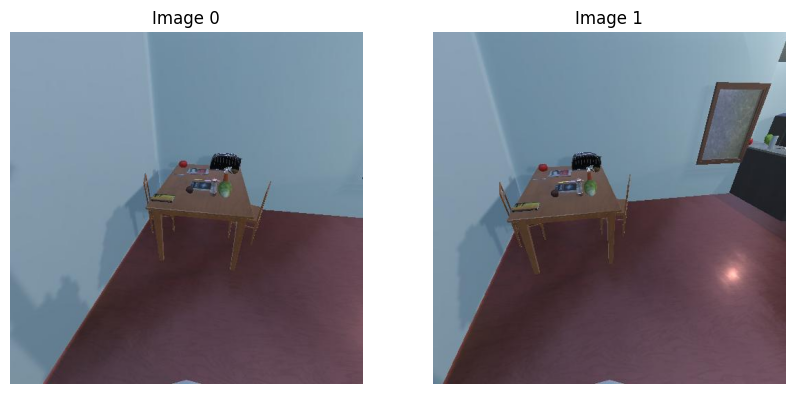

ID: 10
Question: The first image is from the beginning of the video and the second image is from the end. How did the camera likely move when shooting the video?
Choices: ['rotated right', 'rotated left']
Correct: rotated right


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import io

i = 10  # choose any index

example = dataset["train"][i]

# load images
images = [Image.open(io.BytesIO(im_bytes)).convert("RGB")
          for im_bytes in example["image_bytes"]]

# show images
fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))

if len(images) == 1:
    axes = [axes]

for j, (ax, img) in enumerate(zip(axes, images)):
    ax.imshow(img)
    ax.set_title(f"Image {j}")
    ax.axis("off")

plt.show()

# print question + answers
print(f"ID: {i}")
print("Question:", example["question"])
print("Choices:", example["answers"])
print("Correct:", example["correct_answer"])

## Dataset

This notebook uses **SAT: Dynamic Spatial Aptitude Training for Multimodal Language Models**, a dataset designed to improve and evaluate **spatial reasoning** in multimodal language models through dynamic and static visual tasks.

**Dataset citation**

```bibtex
@article{ray2412sat,
  title={Sat: Dynamic spatial aptitude training for multimodal language models, 2025},
  author={Ray, Arijit and Duan, Jiafei and Brown, Ellis and Tan, Reuben and Bashkirova, Dina and Hendrix, Rose and Ehsani, Kiana and Kembhavi, Aniruddha and Plummer, Bryan A and Krishna, Ranjay and others},
  journal={URL https://arxiv.org/abs/2412.07755},
  volume={1},
  number={7}
}
```

Code for loading, inspecting, and visualizing the SAT dataset was written by **Masoud Jafaripour** for analysis and VLM evaluation purposes.
This code is **not affiliated with the dataset authors**.